<a href="https://colab.research.google.com/github/Rustam99-eng/Classification-of-requests-by-topic/blob/main/Classification_of_requests_by_topic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Загрузим датасет
!wget https://storage.yandexcloud.net/my.files/archive.zip

--2026-04-06 19:25:07--  https://storage.yandexcloud.net/my.files/archive.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16861699 (16M) [application/x-zip-compressed]
Saving to: ‘archive.zip’

archive.zip         100%[===================>]  16.08M  8.43MB/s    in 1.9s    

2026-04-06 19:25:10 (8.43 MB/s) - ‘archive.zip’ saved [16861699/16861699]



In [2]:
# Разархивируем датасета во временную папку 'dataset'
!unzip -qo "archive.zip" -d ./dataset

In [3]:
# Библиотека матричного вычисления
import numpy as np
# Библиотека для работы с данными
import pandas as pd
# Библиотека для работы с регулярными выражениями
import re
# Библиотека для работы с фреймворком TensorFlow
import tensorflow as tf
# Библиотеки для построения графиков и их стилизации
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Утилита для расщепления выборки
from sklearn.model_selection import train_test_split

# Необходимые метрики для построения Матрицы ошибок и отчета о классификации
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
# Загружаем данные в DataFrame
address = "/content/dataset/aa_dataset-tickets-multi-lang-5-2-50-version.csv"
df = pd.read_csv(address, low_memory=False)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   24749 non-null  object
 1   body      28587 non-null  object
 2   answer    28580 non-null  object
 3   type      28587 non-null  object
 4   queue     28587 non-null  object
 5   priority  28587 non-null  object
 6   language  28587 non-null  object
 7   version   28587 non-null  int64 
 8   tag_1     28587 non-null  object
 9   tag_2     28574 non-null  object
 10  tag_3     28451 non-null  object
 11  tag_4     25529 non-null  object
 12  tag_5     14545 non-null  object
 13  tag_6     5874 non-null   object
 14  tag_7     2040 non-null   object
 15  tag_8     565 non-null    object
dtypes: int64(1), object(15)
memory usage: 3.5+ MB


In [8]:
# Проверяем уникальные значения в колонке языки
df['language'].unique()

array(['de', 'en'], dtype=object)

In [9]:
print(df.language.value_counts())

language
en    16338
de    12249
Name: count, dtype: int64


In [10]:
# Выполним фильтр данных, где в обучении модели будут участвовать только записи на английском языке
df = df[df['language'] == 'en']

In [11]:
df.shape

(16338, 16)

In [12]:
# Проверим содержимое
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
5,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN


In [13]:
# Проверяем какие типы обращений содержатся в таблице
df['type'].unique()

array(['Incident', 'Request', 'Problem', 'Change'], dtype=object)

In [14]:
print(df.type.value_counts())

type
Incident    6571
Request     4665
Problem     3397
Change      1705
Name: count, dtype: int64


In [15]:
type_values = df.type.value_counts()

In [16]:
type_list = type_values.index.tolist()
for i, topic in enumerate(type_list, 1):
    print(f"{i}. {topic}")

1. Incident
2. Request
3. Problem
4. Change


In [17]:
# Составляем словарь из типов обращений пользователей
type_class = {}
for idx, topic in enumerate(type_list):
    type_class[topic] = idx

print("\nИтоговый словарь классов:")
for type, idx in type_class.items():
    print(f"{idx}: {type}")

# Проверяем, что действительно 4 классов
print(f"\nКоличество классов: {len(type_class)}")


Итоговый словарь классов:
0: Incident
1: Request
2: Problem
3: Change

Количество классов: 4


In [18]:
type_class

{'Incident': 0, 'Request': 1, 'Problem': 2, 'Change': 3}

In [19]:
# Оставляем только нужные для обучения модели колонки
df = df[['body', 'type']]

In [20]:
# Общая функция преобразования строки к multi-вектору
# На входе данные и словарь сопоставления подстрок классам

def str2multiOHE(param, class_dict):
    """
    Преобразует тему новости в one-hot вектор

    Args:
        param: строка с темой новости
        class_dict: словарь соответствия тем и индексов

    Returns:
        numpy array: one-hot вектор
    """
    # Определение размерности выходного вектора
    num_classes = len(class_dict)

    # Создание нулевого вектора
    result = np.zeros(num_classes)

    # Устанавливаем 1 в соответствующей позиции
    result[class_dict[param]] = 1.

    return result

In [21]:
# Тестирование функции
N = 154
print(f'\nТест функции:')
print(f'Тематика: {df.type.iloc[N]}')
print(f'Тематика в формате OHE: {str2multiOHE(df.type.iloc[N], type_class)}')


Тест функции:
Тематика: Request
Тематика в формате OHE: [0. 1. 0. 0.]


In [22]:
# Получаем индекс колонки с очищенными темами
COL_TYPE = df.columns.get_loc('type')

In [23]:
def get_row_data(row):
    """
    Получает one-hot вектор для одной строки DataFrame
    """
    return str2multiOHE(row[COL_TYPE], type_class)

def get_train_data(dataFrame):
    """
    Формирует обучающую выборку y из всего DataFrame

    Args:
        dataFrame: pandas DataFrame с данными

    Returns:
        numpy array: матрица one-hot векторов
    """
    y_data = []

    for idx, row in dataFrame.iterrows():
        y = get_row_data(row)
        y_data.append(y)

    return np.array(y_data)

In [24]:
# Формирование выборки из загруженного набора данных
y = get_train_data(df)

print(f"\nФорма y: {y.shape}")
print(f"Пример одного вектора: {y[154]}")

/tmp/ipykernel_25136/1328364599.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return str2multiOHE(row[COL_TYPE], type_class)



Форма y: (16338, 4)
Пример одного вектора: [0. 1. 0. 0.]


In [25]:
x = df['body'].to_numpy()

In [26]:
# Предобработка текста
def clean_text(text):
    # Приведение к нижнему регистру
    text = text.lower()
    # Удаление спецсимволов и цифр
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()
    return text

x_clean = [clean_text(body) for body in x]

In [27]:
# Проверяем, нет ли пустых заголовков после очистки
empty_titles = [i for i, text in enumerate(x_clean) if len(text) == 0]
print(f"Найдено пустых заголовков после очистки: {len(empty_titles)}")

# Если есть пустые заголовки, удаляем соответствующие записи
if len(empty_titles) > 0:
    print(f"Удаляем {len(empty_titles)} записей с пустыми заголовками")
    # Создаем маску для непустых заголовков
    mask = [len(text) > 0 for text in x_clean]
    x_clean = [x_clean[i] for i in range(len(x_clean)) if mask[i]]
    y = y[mask]
    print(f"Новый размер данных: {len(x_clean)} заголовков")

# Преобразуем one-hot обратно в метки для стратификации
y_labels = np.argmax(y, axis=1)

Найдено пустых заголовков после очистки: 0


In [28]:
# Разделение на обучающую и тестовую выборки
x_train, x_test, y_train, y_test = train_test_split(
    x_clean, y, test_size=0.2, random_state=42,
    stratify=y_labels  # Добавляем стратификацию для сохранения распределения классов
)

In [29]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# Параметры
max_words = 6000  # максимальный размер словаря
max_len = 100      # максимальная длина заголовка

# Токенизация
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(x_train)

# Преобразование в последовательности
X_train_seq = tokenizer.texts_to_sequences(x_train)
X_test_seq = tokenizer.texts_to_sequences(x_test)

# Паддинг
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

Выполним настройку архитектуры модели, её компиляцию и обучение

In [30]:
from keras.layers import GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense, SpatialDropout1D, BatchNormalization, Dropout, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Embedding(max_words, 100),

    SpatialDropout1D(0.3),

    # Conv1D слои для быстрого извлечения признаков
    # Уменьшают временную размерность в 2 раза
    Conv1D(128, 3, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),

    Conv1D(64, 3, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),

    # После пулинга последовательность стала короче в 4 раза
    # LSTM теперь работает с меньшей последовательностью
    Bidirectional(LSTM(32, dropout=0.2)),

    BatchNormalization(),

    Dense(64, activation='relu'),
    Dropout(0.4),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.001,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

# Обучение
history = model.fit(
    X_train_pad, y_train,
    epochs=15,  # Меньше эпох
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.6607 - loss: 0.7356 - val_accuracy: 0.7598 - val_loss: 0.6894 - learning_rate: 0.0010
Epoch 2/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7805 - loss: 0.4381 - val_accuracy: 0.8072 - val_loss: 0.4257 - learning_rate: 0.0010
Epoch 3/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8117 - loss: 0.3806 - val_accuracy: 0.8133 - val_loss: 0.3793 - learning_rate: 0.0010
Epoch 4/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8379 - loss: 0.3441 - val_accuracy: 0.8283 - val_loss: 0.3570 - learning_rate: 0.0010
Epoch 5/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8672 - loss: 0.2981 - val_accuracy: 0.8421 - val_loss: 0.3370 - learning_rate: 0.0010
Epoch 6/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8900 - loss: 0.2565 - val_accuracy: 0.8550 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 7/15
201/205 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9114 - loss: 0

Создадим матрицу ошибок:

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


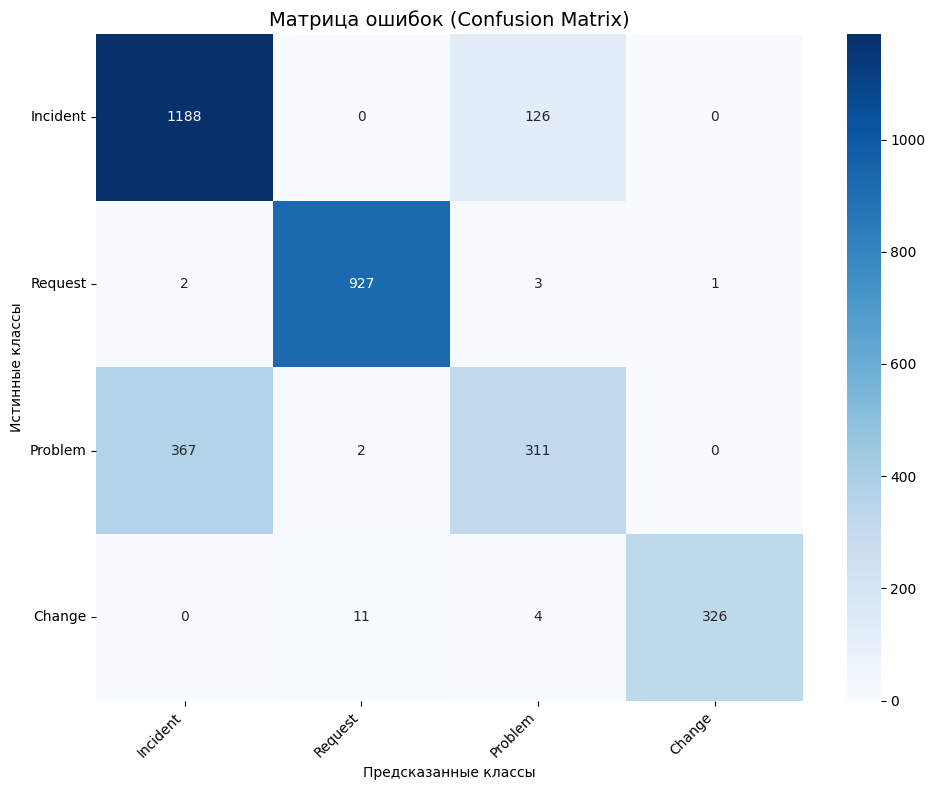


Матрица ошибок (числа):
[[1188    0  126    0]
 [   2  927    3    1]
 [ 367    2  311    0]
 [   0   11    4  326]]

МЕТРИКИ ТОЧНОСТИ РАСПОЗНАВАНИЯ
Общая точность (Overall Accuracy): 0.8421 (84.21%)
Средняя точность по классам (Average Accuracy): 0.8278 (82.78%)
Средневзвешенная точность (Weighted Accuracy): 0.8421 (84.21%)

--------------------------------------------------
ТОЧНОСТЬ ПО КАЖДОМУ КЛАССУ:
--------------------------------------------------
Incident: 0.9041 (90.41%) - 1188/1314
Request: 0.9936 (99.36%) - 927/933
Problem: 0.4574 (45.74%) - 311/680
Change: 0.9560 (95.60%) - 326/341

Отчет о классификации:
              precision    recall  f1-score   support

    Incident       0.76      0.90      0.83      1314
     Request       0.99      0.99      0.99       933
     Problem       0.70      0.46      0.55       680
      Change       1.00      0.96      0.98       341

    accuracy                           0.84      3268
   macro avg       0.86      0.83      0.84      

In [37]:
# Получаем предсказания для тестовой выборки
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Создаем матрицу ошибок
cm = confusion_matrix(y_true, y_pred)

# Инвертируем словарь классов
idx_to_class = {v: k for k, v in type_class.items()}
class_names = [idx_to_class[i] for i in range(len(type_class))]

# Визуализация матрицы ошибок
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=14)
plt.xlabel('Предсказанные классы')
plt.ylabel('Истинные классы')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Вывод матрицы ошибок в текстовом виде
print("\nМатрица ошибок (числа):")
print(cm)

# Вычисление различных метрик точности
# 1. Общая точность (Overall Accuracy)
overall_accuracy = np.trace(cm) / np.sum(cm)

# 2. Средняя точность по классам (Average Accuracy)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
average_accuracy = np.mean(class_accuracies)

# 3. Средневзвешенная точность (Weighted Average Accuracy)
weighted_accuracy = np.average(class_accuracies, weights=cm.sum(axis=1))

# Вывод метрик точности
print("\n" + "="*50)
print("МЕТРИКИ ТОЧНОСТИ РАСПОЗНАВАНИЯ")
print("="*50)
print(f"Общая точность (Overall Accuracy): {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Средняя точность по классам (Average Accuracy): {average_accuracy:.4f} ({average_accuracy*100:.2f}%)")
print(f"Средневзвешенная точность (Weighted Accuracy): {weighted_accuracy:.4f} ({weighted_accuracy*100:.2f}%)")

# Вывод точности по каждому классу
print("\n" + "-"*50)
print("ТОЧНОСТЬ ПО КАЖДОМУ КЛАССУ:")
print("-"*50)
for i, class_name in enumerate(class_names):
    class_acc = class_accuracies[i]
    correct = cm[i, i]
    total = cm[i, :].sum()
    print(f"{class_name}: {class_acc:.4f} ({class_acc*100:.2f}%) - {correct}/{total}")

# Отчет о классификации
print("\nОтчет о классификации:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [33]:
#примеры для предсказания
examples = {
    "Incident": "The Wi-Fi router has failed due to a short circuit. Users are unable to connect to the Internet.",
    "Request": "Fraudsters hacked my personal account. What should I do in this situation?",
    "Problem": "Users experience frequent crashes due to memory leak in version 2.1.",
    "Change": "We need to take the time to update the software on our employees' work computers.",
    "Incident": "The Wi-Fi router has failed due to a short circuit. Users are unable to connect to the Internet.",
    "Request": "Fraudsters hacked my personal account. What should I do in this situation?",
    "Problem": "Users experience frequent crashes due to memory leak in version 2.1.",
    "Change": "We need to update the software on employees' computers.",
    "Incident": "Database server crashed unexpectedly at 3 AM. All customer transactions are frozen.",
    "Request": "Please grant me access to the financial reports folder.",
    "Problem": "The application becomes extremely slow with large files.",
    "Change": "Schedule maintenance to upgrade the database next weekend.",
    "Incident": "Email service is down. Employees cannot send or receive messages.",
    "Request": "Could you install Python on my work computer?",
    "Problem": "VPN connection drops every 30 minutes.",
    "Change": "Replace all network switches on floor 3 on Friday."
}


# Инвертируем словарь классов
idx_to_class = {v: k for k, v in type_class.items()}

# Подготавливаем и предсказываем примеры
for expected_topic, text in examples.items():
    # Очистка и токенизация
    text_clean = clean_text(text)
    sequence = tokenizer.texts_to_sequences([text_clean])
    padded = pad_sequences(sequence, maxlen=100, padding='post')

    # Предсказание
    pred = model.predict(padded, verbose=0)[0]
    predicted_idx = np.argmax(pred)
    predicted_topic = idx_to_class[predicted_idx]

    # Вывод результата
    print(f"Ожидаемый тип: {expected_topic}")
    print(f"Предсказанный тип: {predicted_topic}")
    print(f"Результат совпадает? {'Да' if expected_topic == predicted_topic else 'Нет'}")

Ожидаемый тип: Incident
Предсказанный тип: Incident
Результат совпадает? Да
Ожидаемый тип: Request
Предсказанный тип: Request
Результат совпадает? Да
Ожидаемый тип: Problem
Предсказанный тип: Incident
Результат совпадает? Нет
Ожидаемый тип: Change
Предсказанный тип: Incident
Результат совпадает? Нет


In [34]:
test_accuracy = model.evaluate(X_test_pad, y_test)[1]
print(f"Контрольная выборка - {test_accuracy:.4f}")

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8421 - loss: 0.3370
Контрольная выборка - 0.8421
